Notes:
- Check regression layer, model compile and callbacks have been correctly implemented.
- Check if model needs to be further fine tuned in steps.
- Add learning rate calculatons to each model.

# EfficientNet Transfer Learning - CNN + Regressor

In [ ]:
!pip install catboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 99.2/99.2 MB 22.7 MB/s eta 0:00:00


### Load Libraries

In [ ]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing.image import ImageDataGenerator, load_img
from tensorflow.keras.applications import (
    EfficientNetB0, EfficientNetB1, EfficientNetB2, EfficientNetB3,
    EfficientNetB4, EfficientNetB5, EfficientNetB6, EfficientNetB7
)
from tensorflow.keras.applications.efficientnet import preprocess_input
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Input, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error
from scipy.stats import pearsonr

# Regressor imports
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from xgboost import XGBRegressor
from sklearn.linear_model import Ridge
from sklearn.svm import SVR
from sklearn.ensemble import (
    RandomForestRegressor, GradientBoostingRegressor,
    AdaBoostRegressor, VotingRegressor
)
from sklearn.neural_network import MLPRegressor
from sklearn.neighbors import KNeighborsRegressor
import lightgbm as lgb
from catboost import CatBoostRegressor

#### For Reproducibility

In [ ]:
SEED = 42
np.random.seed(SEED)

### Load Data

In [ ]:
# Use local paths below if data saved in local dir used.

# # Set Local Paths
# BASE_DIR   = os.path.join(os.getcwd(), 'Data', 'Data')
# IMAGES_DIR = os.path.join(BASE_DIR, 'Images')
# LABELS_CSV = os.path.join(BASE_DIR, 'data.csv')

# print("BASE_DIR:", BASE_DIR)
# print("Contents:", os.listdir(BASE_DIR))
# print("Images dir:", IMAGES_DIR)
# print("Labels file:", LABELS_CSV)

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
BASE_DIR   = '/content/drive/MyDrive/Colab Notebooks/Masters in Applied Data Science/ML2/Data'
IMAGES_DIR = os.path.join(BASE_DIR, 'Images')
LABELS_CSV = os.path.join(BASE_DIR, 'data.csv')

print("BASE_DIR:", BASE_DIR)
print("Contents:", os.listdir(BASE_DIR))
print("Images dir:", IMAGES_DIR)
print("Labels file:", LABELS_CSV)

BASE_DIR: /content/drive/MyDrive/Colab Notebooks/Masters in Applied Data Science/ML2/Data
Contents: ['data.csv', '.DS_Store', 'Images']
Images dir: /content/drive/MyDrive/Colab Notebooks/Masters in Applied Data Science/ML2/Data/Images
Labels file: /content/drive/MyDrive/Colab Notebooks/Masters in Applied Data Science/ML2/Data/data.csv


In [ ]:
# Load the labels DataFrame
df = pd.read_csv(LABELS_CSV)

# Convert gender to binary feature
df['gender_binary'] = df['gender'].map({'male': 0, 'female': 1})

In [ ]:
# Build full image paths from the `name` column:
df['file_path'] = df['name'].apply(lambda fn: os.path.join(IMAGES_DIR, fn))

# Drop any rows whose image file isn’t actually on disk
df = df[df['file_path'].apply(os.path.exists)].reset_index(drop=True)

In [ ]:
# Split into train vs test by your `is_training` flag:
train_df = df[df['is_training'] == 1].reset_index(drop=True)
test_df  = df[df['is_training'] == 0].reset_index(drop=True)

print(f"Total: {len(df)}  •  Train: {len(train_df)}  •  Test: {len(test_df)}")
train_df.head()

Total: 3962  •  Train: 3210  •  Test: 752


,Unnamed: 0,bmi,gender,is_training,name,gender_binary,file_path
0,0,34.207396,Male,1,img_0.bmp,NaN,/content/drive/MyDrive/Colab Notebooks/Masters...
1,1,26.453720,Male,1,img_1.bmp,NaN,/content/drive/MyDrive/Colab Notebooks/Masters...
2,2,34.967561,Female,1,img_2.bmp,NaN,/content/drive/MyDrive/Colab Notebooks/Masters...
3,3,22.044766,Female,1,img_3.bmp,NaN,/content/drive/MyDrive/Colab Notebooks/Masters...
4,6,25.845588,Female,1,img_6.bmp,NaN,/content/drive/MyDrive/Colab Notebooks/Masters...


(np.float64(-0.5), np.float64(223.5), np.float64(223.5), np.float64(-0.5))

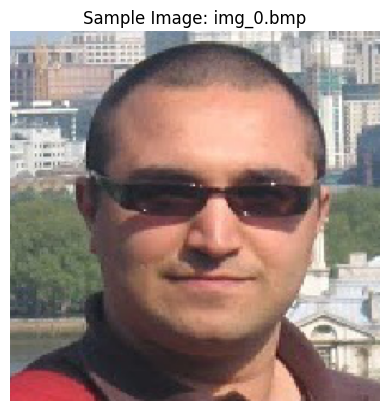

In [ ]:
# Display One Sample Image
from tensorflow.keras.preprocessing.image import load_img

# Pick the first training sample
sample_path = train_df['file_path'].iloc[0]

# Resize to 224×224 for visualization
img = load_img(sample_path, target_size=(224, 224))
plt.imshow(img)
plt.title(f"Sample Image: {os.path.basename(sample_path)}")
plt.axis('off')

### Section 1.1: Baseline CNN Model Training: EfficientNet B0–B7

##### Workflow:
- All 8 EfficientNet models (B0–B7) will be trained as baeline models using 5 epochs.
- Based on the model evaluation results, the best EfficientNet model will be selected and further fine tuned forfeature extraction  

In [ ]:
# Configuration for each EfficientNet variant: (model_class, input_size)
eff_configs = [
    (EfficientNetB0, 224), (EfficientNetB1, 240), (EfficientNetB2, 260),
    (EfficientNetB3, 300), (EfficientNetB4, 380), (EfficientNetB5, 456),
    (EfficientNetB6, 528), (EfficientNetB7, 600)
]

results = {}

for ModelClass, img_size in eff_configs:
    name = ModelClass.__name__
    print(f"\nTraining baseline with {name} (input {img_size}×{img_size})")

    # Prepare data generators (no augmentation for baseline)
    datagen = ImageDataGenerator(preprocessing_function=preprocess_input, validation_split=0.2)
    train_gen = datagen.flow_from_dataframe(
        train_df, x_col='file_path', y_col='bmi',
        subset='training', target_size=(img_size, img_size),
        batch_size=32, class_mode='raw', shuffle=True, seed=SEED
    )
    val_gen = datagen.flow_from_dataframe(
        train_df, x_col='file_path', y_col='bmi',
        subset='validation', target_size=(img_size, img_size),
        batch_size=32, class_mode='raw', shuffle=False, seed=SEED
    )

    # Build model: base + GAP + dense regression head
    inp = Input(shape=(img_size, img_size, 3))
    base = ModelClass(include_top=False, input_tensor=inp, weights='imagenet')
    base.trainable = False
    x = GlobalAveragePooling2D()(base.output)
    x = Dropout(0.2)(x)
    out = Dense(1, activation='linear')(x)
    model = Model(inp, out)
    model.compile(optimizer='adam', loss='mse', metrics=['mae'])

    # Train for a few epochs
    history = model.fit(
        train_gen,
        validation_data=val_gen,
        epochs=5,
        callbacks=[EarlyStopping(monitor='val_loss', patience=2, restore_best_weights=True)],
        verbose=2
    )

    # Evaluate on validation set
    val_preds = model.predict(val_gen)
    y_true = val_gen.labels
    mse = mean_squared_error(y_true, val_preds)
    mae = mean_absolute_error(y_true, val_preds)
    corr, _ = pearsonr(y_true, val_preds.ravel())
    results[name] = {'mse': mse, 'mae': mae, 'corr': corr}
    print(f"{name} → MSE: {mse:.3f}, MAE: {mae:.3f}, Pearson r: {corr:.3f}")

# Summarize baseline results
baseline_df = pd.DataFrame(results).T.sort_values('mse')
print(baseline_df)


Training baseline with EfficientNetB0 (input 224×224)
Found 2568 validated image filenames.
Found 642 validated image filenames.
16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/5
81/81 - 2477s - 31s/step - loss: 768.6581 - mae: 26.2381 - val_loss: 474.9774 - val_mae: 20.3505
Epoch 2/5
81/81 - 10s - 124ms/step - loss: 344.2926 - mae: 16.2695 - val_loss: 198.3507 - val_mae: 11.6931
Epoch 3/5
81/81 - 10s - 126ms/step - loss: 164.0197 - mae: 9.8687 - val_loss: 101.4342 - val_mae: 7.5842
Epoch 4/5
81/81 - 10s - 123ms/step - loss: 107.5629 - mae: 7.7416 - val_loss: 76.5958 - val_mae: 6.6218
Epoch 5/5
81/81 - 10s - 124ms/step - loss: 90.2459 - mae: 7.2393 - val_loss: 71.0218 - val_mae: 6.4912
21/21 ━━━━━━━━━━━━━━━━━━━━ 13s 352ms/step
EfficientNetB0 → MSE: 71.022, MAE: 6.491, Pearson r: 0.066

Training baseline with EfficientNetB1 (input 240×240)
Found 2568 validated image filenames.
Found 642 validated image filenames.
27018416/27018416 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/5
81/81 - 66s - 811ms/step - loss: 778.5287 - mae: 26.4205 - val_loss: 499.9954 - val_mae: 20.9705
Epoch 2/5
81/81 - 10s - 124ms/step - loss: 328.0324 - mae: 15.8316 - val_loss: 218.5501 - val_mae: 12.4785
Epoch 3/5
81/81 - 11s - 130ms/step - loss: 160.5714 - mae: 9.8287 - val_loss: 116.0466 - val_mae: 8.1926
Epoch 4/5
81/81 - 10s - 126ms/step - loss: 106.7816 - mae: 7.7757 - val_loss: 84.2028 - val_mae: 6.8399
Epoch 5/5
81/81 - 10s - 126ms/step - loss: 91.8243 - mae: 7.3216 - val_loss: 74.5009 - val_mae: 6.5101
21/21 ━━━━━━━━━━━━━━━━━━━━ 17s 474ms/step
EfficientNetB1 → MSE: 74.501, MAE: 6.510, Pearson r: 0.089

Training baseline with EfficientNetB2 (input 260×260)
Found 2568 validated image filenames.
Found 642 validated image filenames.
31790344/31790344 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


...

Epoch 1/5
81/81 - 137s - 2s/step - loss: 775.1288 - mae: 26.3925 - val_loss: 479.2574 - val_mae: 20.3988
Epoch 2/5
81/81 - 31s - 381ms/step - loss: 338.8366 - mae: 16.0839 - val_loss: 204.6016 - val_mae: 11.7398
Epoch 3/5
81/81 - 31s - 381ms/step - loss: 165.0527 - mae: 9.9034 - val_loss: 111.5265 - val_mae: 8.0519
Epoch 4/5
81/81 - 31s - 381ms/step - loss: 111.1752 - mae: 7.9080 - val_loss: 86.4448 - val_mae: 7.1524
Epoch 5/5
81/81 - 31s - 381ms/step - loss: 95.6920 - mae: 7.4839 - val_loss: 79.1443 - val_mae: 6.9365
21/21 ━━━━━━━━━━━━━━━━━━━━ 29s 833ms/step
EfficientNetB5 → MSE: 79.144, MAE: 6.937, Pearson r: 0.041

Training baseline with EfficientNetB6 (input 528×528)
Found 2568 validated image filenames.
Found 642 validated image filenames.
165234480/165234480 ━━━━━━━━━━━━━━━━━━━━ 8s 0us/step


/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/5
81/81 - 190s - 2s/step - loss: 767.1041 - mae: 26.2007 - val_loss: 451.1092 - val_mae: 19.7058
Epoch 2/5
81/81 - 53s - 653ms/step - loss: 320.6354 - mae: 15.4475 - val_loss: 179.8801 - val_mae: 10.8951
Epoch 3/5
81/81 - 53s - 650ms/step - loss: 154.0141 - mae: 9.5051 - val_loss: 100.1568 - val_mae: 7.6675
Epoch 4/5
81/81 - 53s - 652ms/step - loss: 108.0215 - mae: 7.8413 - val_loss: 81.6953 - val_mae: 7.0297
Epoch 5/5
81/81 - 53s - 651ms/step - loss: 94.1715 - mae: 7.4707 - val_loss: 76.2293 - val_mae: 6.8722
21/21 ━━━━━━━━━━━━━━━━━━━━ 37s 1s/step
EfficientNetB6 → MSE: 76.229, MAE: 6.872, Pearson r: 0.093

Training baseline with EfficientNetB7 (input 600×600)
Found 2568 validated image filenames.
Found 642 validated image filenames.
258076736/258076736 ━━━━━━━━━━━━━━━━━━━━ 12s 0us/step


/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/5
81/81 - 255s - 3s/step - loss: 734.8268 - mae: 25.4826 - val_loss: 403.6621 - val_mae: 18.4050
Epoch 2/5
81/81 - 88s - 1s/step - loss: 274.0519 - mae: 13.8769 - val_loss: 150.2752 - val_mae: 9.5291
Epoch 3/5
81/81 - 88s - 1s/step - loss: 130.8445 - mae: 8.6229 - val_loss: 90.0197 - val_mae: 7.2943
Epoch 4/5
81/81 - 88s - 1s/step - loss: 99.7449 - mae: 7.6466 - val_loss: 78.3587 - val_mae: 6.9397
Epoch 5/5
81/81 - 88s - 1s/step - loss: 92.2354 - mae: 7.4646 - val_loss: 74.3995 - val_mae: 6.8068
21/21 ━━━━━━━━━━━━━━━━━━━━ 48s 2s/step
EfficientNetB7 → MSE: 74.399, MAE: 6.807, Pearson r: 0.049
                      mse       mae      corr
EfficientNetB0  71.021809  6.491164  0.066186
EfficientNetB7  74.399474  6.806757  0.048641
EfficientNetB1  74.500906  6.510146  0.088733
EfficientNetB6  76.229355  6.872172  0.092509
EfficientNetB5  79.144271  6.936520  0.041386
EfficientNetB4  80.135928  6.995552  0.048749
EfficientNetB2  81.909524  6.898978  0.012866
EfficientNetB3  85.109262

#### Model Selection:
- The **EfficientNetB6** has the highest Pearson -R statistic of 0.0925. Therefore, the model is picked for fin tuning.
- The EfficientNetB0 model has the lowest error (MSE ≈ 71.02, MAE ≈ 6.49).

### Section 1.2: Fine-Tuning the Best EfficientNet Model

##### Workflow:

##### The best performing EfficientNet Model is further fine tuned by implementing the following teatments:
- The last 30 layers of the base model are unforzen for fine tuning
- Data augmentation applied to increase the size and diversity of the training dataset due to a limited overall data set of only 4205 pictures. Various data augmentation treatments applied like rotation, width and height shifts, and others.
- The model was trained for 15 epochs to help observe convergence and determine the appropriate epochs for model training.
- The model's loss curve, over the 15 epochs, is plotted to provide a visualizatin of the flattening loss curve.    

Fine-tuning EfficientNetB3 with input size (300, 300)
Found 2568 validated image filenames.
Found 642 validated image filenames.
43941136/43941136 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/15
81/81 - 1045s - 13s/step - loss: 205.0632 - mae: 10.5680 - val_loss: 298.6197 - val_mae: 15.2581
Epoch 2/15
81/81 - 66s - 817ms/step - loss: 44.9730 - mae: 5.0607 - val_loss: 64.5306 - val_mae: 6.4301
Epoch 3/15
81/81 - 66s - 815ms/step - loss: 35.9759 - mae: 4.4795 - val_loss: 73.7955 - val_mae: 7.3298
Epoch 4/15
81/81 - 66s - 819ms/step - loss: 31.6212 - mae: 4.2890 - val_loss: 49.1727 - val_mae: 5.3970
Epoch 5/15
81/81 - 66s - 816ms/step - loss: 27.4172 - mae: 3.9775 - val_loss: 38.2670 - val_mae: 4.8137
Epoch 6/15
81/81 - 66s - 820ms/step - loss: 24.1784 - mae: 3.7431 - val_loss: 34.6156 - val_mae: 4.4539
Epoch 7/15
81/81 - 66s - 819ms/step - loss: 21.3530 - mae: 3.5138 - val_loss: 35.3927 - val_mae: 4.4401
Epoch 8/15
81/81 - 66s - 818ms/step - loss: 18.7104 - mae: 3.3271 - val_loss: 37.5120 - val_mae: 4.6514
Epoch 9/15
81/81 - 66s - 815ms/step - loss: 16.9863 - mae: 3.1738 - val_loss: 52.4958 - val_mae: 5.9560


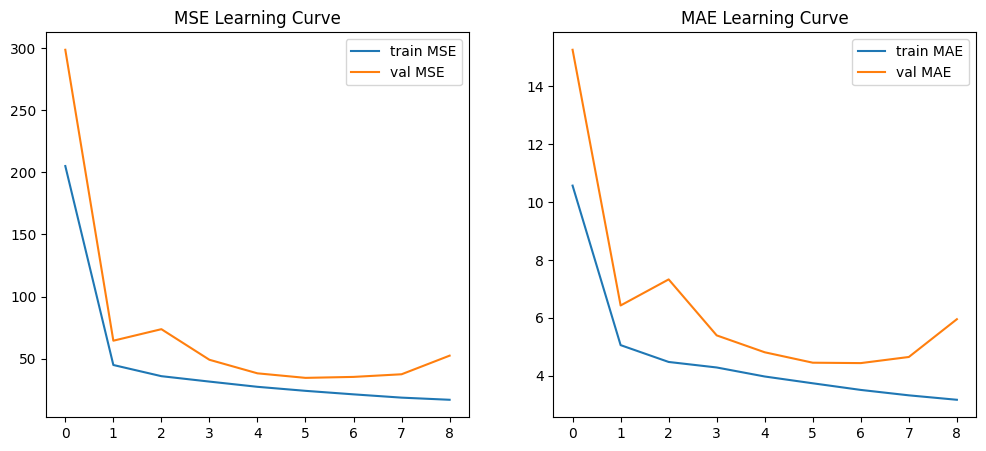

In [ ]:
# Model selection
ModelClass = EfficientNetB3
img_size = (300, 300)  # EfficientNetB3’s default input resolution
print(f"Fine-tuning EfficientNetB3 with input size {img_size}")

# Data augmentation setup
aug_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    validation_split=0.2,
    rotation_range=20,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.1,
    horizontal_flip=True
)

train_aug = aug_datagen.flow_from_dataframe(
    train_df, x_col='file_path', y_col='bmi',
    subset='training', target_size=img_size,
    batch_size=32, class_mode='raw', shuffle=True, seed=SEED
)
val_aug = aug_datagen.flow_from_dataframe(
    train_df, x_col='file_path', y_col='bmi',
    subset='validation', target_size=img_size,
    batch_size=32, class_mode='raw', shuffle=False, seed=SEED
)

# Build & fine-tune
inp = Input(shape=img_size + (3,))
base = ModelClass(include_top=False, input_tensor=inp, weights='imagenet')
for layer in base.layers[-30:]:
    layer.trainable = True

x = GlobalAveragePooling2D()(base.output)
x = Dropout(0.3)(x)
out = Dense(1, activation='linear', kernel_regularizer='l2')(x)
ft_model = Model(inp, out)

ft_model.compile(optimizer='adam', loss='mse', metrics=['mae'])
es = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

history = ft_model.fit(
    train_aug,
    validation_data=val_aug,
    epochs=15,
    callbacks=[es],
    verbose=2
)

# Plot learning curves
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.plot(history.history['loss'], label='train MSE')
plt.plot(history.history['val_loss'], label='val MSE')
plt.title('MSE Learning Curve')
plt.legend()
plt.subplot(1,2,2)
plt.plot(history.history['mae'], label='train MAE')
plt.plot(history.history['val_mae'], label='val MAE')
plt.title('MAE Learning Curve')
plt.legend()
plt.show()


### Section 2.1: Create Feature Extractor for Regressors

##### Workflow:

-

In [ ]:
# Feature‐extractor with GAP layer
feature_extractor = Model(
    inputs = ft_model.input,
    outputs = ft_model.layers[-3].output
)

# Prepare regression‐ready generators (images + bmi labels),
# applying the same preprocess_input you used for fine‐tuning
reg_datagen = ImageDataGenerator(preprocessing_function=preprocess_input)

train_gen = reg_datagen.flow_from_dataframe(
    train_df,
    x_col='file_path',
    y_col='bmi',
    target_size=img_size,
    batch_size=32,
    class_mode='raw',    # yields (x, y) pairs for regression
    shuffle=False,
    seed=SEED
)

test_gen = reg_datagen.flow_from_dataframe(
    test_df,
    x_col='file_path',
    y_col='bmi',
    target_size=img_size,
    batch_size=32,
    class_mode='raw',
    shuffle=False,
    seed=SEED
)

# Pull out features
# Labels as NumPy arrays
def extract_features(gen, model):
    X_parts, y_parts = [], []
    for batch_X, batch_y in gen:
        feats = model.predict(batch_X, verbose=0)
        X_parts.append(feats)
        y_parts.append(batch_y)
    X = np.vstack(X_parts)
    y = np.concatenate(y_parts)
    return X, y

X_train, y_train = extract_features(train_gen, feature_extractor)
X_test,  y_test  = extract_features(test_gen,  feature_extractor)

# Finally append your gender‐binary column
g_train = train_df['gender_binary'].values.reshape(-1,1)
g_test  = test_df['gender_binary'].values.reshape(-1,1)

X_train = np.hstack([X_train, g_train])
X_test  = np.hstack([X_test,  g_test])

print("Feature matrix shapes:", X_train.shape, X_test.shape)

Found 3210 validated image filenames.
Found 752 validated image filenames.


### Section 2.2: Train & Evaluate Regressors

In [ ]:
# Define your base estimators
base_regs = {
    'XGBoost':       XGBRegressor(random_state=SEED),
    'Ridge':         Ridge(),
    'SVR':           SVR(),
    'RandomForest':  RandomForestRegressor(random_state=SEED),
}

# Wrap each in a simple pipeline that first imputes missing values
regs = {
    name: Pipeline([
        ('imputer', SimpleImputer(strategy='mean')),
        ('model',   estimator)
    ])
    for name, estimator in base_regs.items()
}

# Train, predict, and record metrics
records = []
for name, pipe in regs.items():
    print(f"Training {name!r}...")
    pipe.fit(X_train, y_train)
    preds = pipe.predict(X_test)
    mse = mean_squared_error(y_test, preds)
    mae = mean_absolute_error(y_test, preds)
    r, _ = pearsonr(y_test, preds)
    records.append({
        'Regressor':   name,
        'MSE':         mse,
        'MAE':         mae,
        'Pearson_r':   r
    })

# Build a DataFrame, sorted by best (lowest) MSE
metrics_df = (
    pd.DataFrame(records)
      .set_index('Regressor')
      .sort_values('MSE')
)
display(metrics_df)

# Visualize error metrics (MSE & MAE) side by side
ax = metrics_df[['MSE','MAE']].plot.bar(
    rot=45, figsize=(10,6), title='Regressor Error Metrics'
)
ax.set_ylabel('Error')
plt.tight_layout()
plt.show()

# Visualize Pearson correlation separately
plt.figure(figsize=(8,5))
plt.bar(metrics_df.index, metrics_df['Pearson_r'])
plt.title('Regressor Pearson Correlation')
plt.ylabel('Pearson r')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Section 2.3: Ensemble of Top 3 Regressors

In [ ]:
# # Select top 3 by lowest MSE
# top3 = metrics_df.index[:3].tolist()
# print("Top 3 regressors:", top3)

# ensemble = VotingRegressor(
#     estimators=[(name, regressors[name]) for name in top3]
# )
# ensemble.fit(X_train, y_train)
# preds = ensemble.predict(X_test)
# mse = mean_squared_error(y_test, preds)
# mae = mean_absolute_error(y_test, preds)
# corr, _ = pearsonr(y_test, preds)
# print(f"Ensemble ({top3}) → MSE={mse:.3f}, MAE={mae:.3f}, r={corr:.3f}")

In [ ]:
# Pick the three regressors with lowest MSE
top_three = metrics_df.nsmallest(3, 'MSE').index.tolist()

# Build & fit a VotingRegressor on those
ens = VotingRegressor([(nm, regressors[nm]) for nm in top_three])
ens.fit(X_train, y_train)

# Evaluate ensemble
y_ens = ens.predict(X_test)
ens_metrics = {
    'MSE':        mean_squared_error(y_test, y_ens),
    'MAE':        mean_absolute_error(y_test, y_ens),
    'Pearson_r':  pearsonr(y_test, y_ens)[0]
}

# Add to your metrics table
metrics_df.loc['Ensemble'] = ens_metrics

# Print a nice summary
for name, vals in metrics_df.iterrows():
    print(f"{name:12s} | MSE: {vals['MSE']:.3f} | MAE: {vals['MAE']:.3f} | r: {vals['Pearson_r']:.3f}")

# Visualize error comparison (individual vs. ensemble)
metrics_df[['MSE','MAE']].plot.bar(
    figsize=(10,6), rot=45,
    title='Error Metrics — Models vs. Ensemble'
)
plt.ylabel('Error')
plt.tight_layout()
plt.show()

# Visualize correlation comparison
metrics_df['Pearson_r'].plot.bar(
    figsize=(8,5), rot=45,
    title='Pearson r — Models vs. Ensemble'
)
plt.ylabel('Pearson r')
plt.tight_layout()
plt.show()